# PID lab


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

## Ambient test

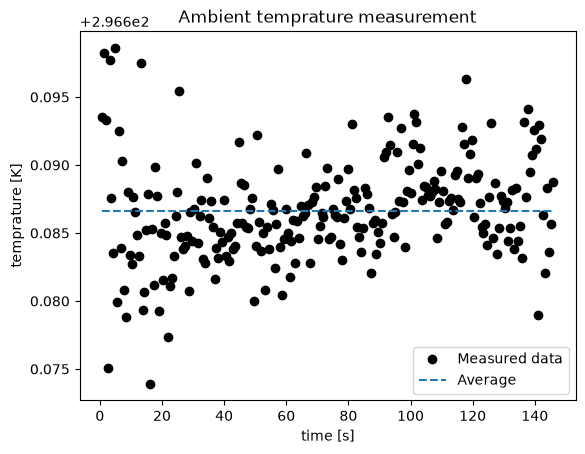

Ambient temprature is measured as:  296.68663691199106 +- 0.003764276512401324 K
Ambient temprature is measured as:  23.53663691199108 +- 0.003764276512401324 C


In [49]:
data = loadmat("Datafiles/Ambient_temp")

time = np.array(data['cm'])[0]
temp = np.array(data['T'])[0]

avg = np.average(temp)
var = np.var(temp)
avg_plot = np.ones(len(temp))*avg


plt.figure()
plt.plot(time, temp, 'ko', label='Measured data')
plt.plot(time, avg_plot, '--', label = 'Average')
plt.xlabel('time [s]')
plt.ylabel('temprature [K]')
plt.legend()
plt.title("Ambient temprature measurement")
plt.savefig("Ambient_temp.pdf")
plt.show()

print('Ambient temprature is measured as: ', avg, '+-', np.sqrt(var), 'K')
print('Ambient temprature is measured as: ', avg-273.15, '+-', np.sqrt(var), 'C')

## Step analysis


/tmp/ipykernel_9960/2725982177.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


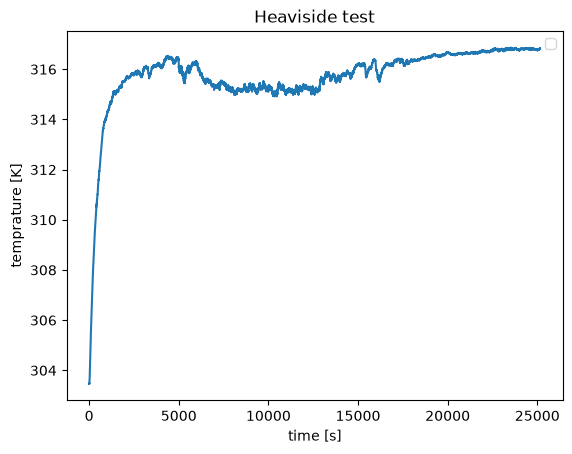

/tmp/ipykernel_9960/2725982177.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


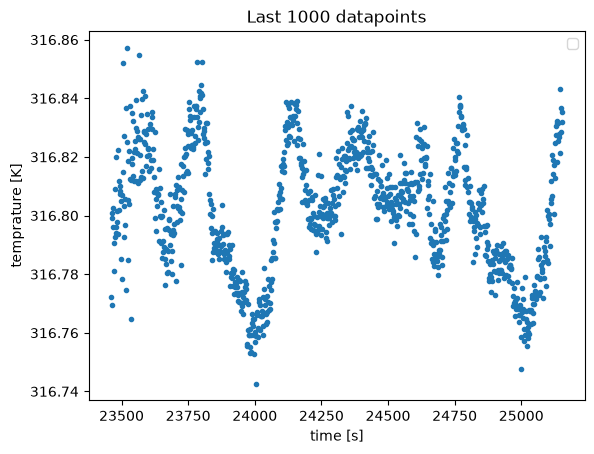

lim t-> inf T(t) ~ 316.8022963579231 +- 0.021056906810112755 K
lim t-> inf T(t) ~ 43.65229635792315 +- 0.021056906810112755 C


In [72]:
data = loadmat("Datafiles/Heaviside_test")

time = np.array(data['cm'])[0]
temp = np.array(data['T'])[0]

#Slice away interupted data
idx = np.where(time != 0)
time = time[idx]
temp = temp[idx]

plt.figure()
plt.plot(time, temp)
plt.xlabel('time [s]')
plt.ylabel('temprature [K]')
plt.legend()
plt.title("Heaviside test")
plt.savefig("Heaviside_test.pdf")
plt.show()

plt.figure()
plt.plot(time[-1000:-1], temp[-1000:-1], '.')
plt.xlabel('time [s]')
plt.ylabel('temprature [K]')
plt.legend()
plt.title("Last 1000 datapoints")
plt.savefig("Heaviside_test_last1000.pdf")
plt.show()


T_inf = np.average(temp[-1000:-1])
T_inf_sigma = np.var(temp[-1000:-1])

print('lim t-> inf T(t) ~', T_inf, '+-', np.sqrt(T_inf_sigma),'K' )
print('lim t-> inf T(t) ~', T_inf-273.15, '+-', np.sqrt(T_inf_sigma),'C' )

## Pulse test
The experiment ran for 30 iterations before the pulse was turned on. We redefine t_0 to be whenever these initial itterations are over. 

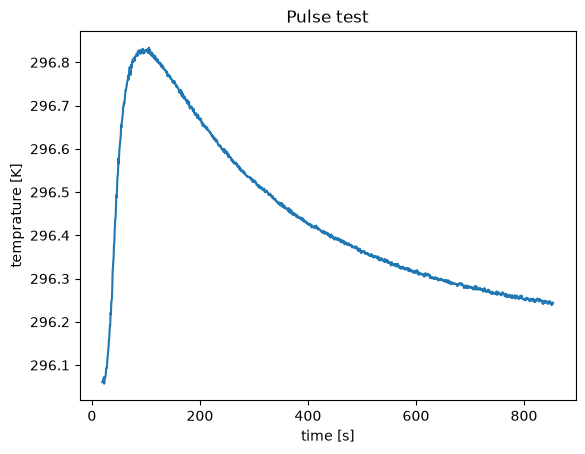

74


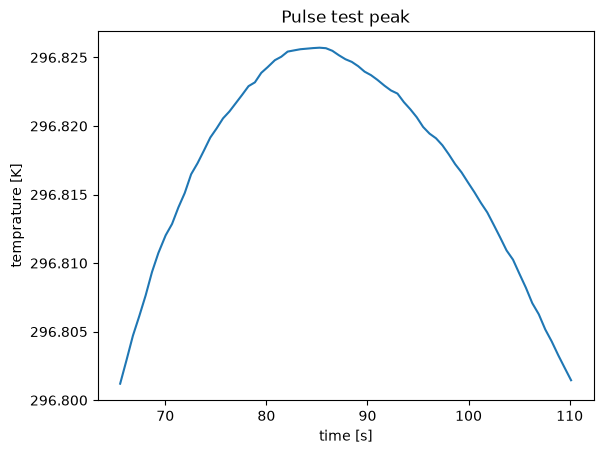

In [ ]:
data = loadmat("Datafiles/Pulse_test")

time = np.array(data['cm'])[0]
temp = np.array(data['T'])[0]

time = time[30:]
temp = temp[30:]

#Slice away interupted data
idx = np.where(time != 0)
time = time[idx]
temp = temp[idx]


plt.figure()
plt.plot(time, temp, label='Measured data')
plt.xlabel('time [s]')
plt.ylabel('temprature [K]')
plt.title("Pulse test")
plt.savefig("Pulse.pdf")
plt.show()

# Raw data is too noisy to locate the peak. We need to use a filter to smooth
# it. Then the maximum value 

window_size = 40
smooth_temp = np.convolve(temp, np.ones(window_size)/window_size, mode='valid')
idx = np.where(smooth_temp>296.80)[0]
print(idx[0])


plt.figure()
plt.plot(time[idx[0]:idx[-1]], smooth_temp[idx[0]:idx[-1]], label='Measured data')
plt.xlabel('time [s]')
plt.ylabel('temprature [K]')
plt.title("Pulse test peak")
plt.show()

# We can see the peak is in the window shown in the second figure, 
# and here the graph looks fairly parabolic. We can try to fit a parabola
# To the raw data, which should quantify where the error of the fitting
# parameters correspond to the the error in our estinmate for the peak. 

time_fit, temp_fit = time[idx[0]:idx[-1]], temp[idx[0]:idx[-1]]
t_0 = np.mean(time_fit)
p, cov = np.polyfit(time_fit-t_0, temp_fit, 2, cov = True)

a,b,c = p
time_peak = -b/(2*a) + t_0
temp_peak = a*time_peak**2 + b*time_peak + c

